# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [ ]:
# !git clone https://github.com/huy20/K4-Track4-Day1-Neuralnetwork

In [ ]:
REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

In [ ]:
%cd /content/K4-Track4-Day1-Neuralnetwork/code
!ls

/content/K4-Track4-Day1-Neuralnetwork/code
data.py    model.py	 plots.py     results_table.py
lab.ipynb  optimizer.py  __pycache__  train.py


In [ ]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch
import torch.nn.functional as F

OUT_DIR   = ".."
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}, Device: {device}")
if device == "cuda": print(torch.cuda.get_device_name(0))

os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx


PyTorch version: 2.11.0+cu130, Device: cuda
Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [ ]:
# Split data if not already done
subprocess.run([sys.executable, f"{REPO_ROOT}/scripts/split_data.py"], check=False)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
print(f"X_tr mean (first 10): {data['X_tr'][:, :10].mean(dim=0)}")
print(f"X_tr std (first 10): {data['X_tr'][:, :10].std(dim=0)}")


Train size: 371847
Val size: 92962
Eval size: 116203
Majority guess val accuracy: 0.4876
X_tr mean (first 10): tensor([ 8.7826e-05, -1.1486e-05,  5.4248e-08, -3.2106e-04, -4.8937e-06,
        -2.9291e-05,  4.5972e-05, -2.1969e-05,  2.8984e-05, -4.1533e-05],
       device='cuda:0')
X_tr std (first 10): tensor([1.0001, 1.0001, 1.0001, 1.0000, 1.0000, 1.0000, 0.9999, 1.0000, 0.9999,
        1.0001], device='cuda:0')


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

Params: 47879
Logits shape: torch.Size([8, 7])
Step 0 val loss: 1.9083 (Expected ~1.946)


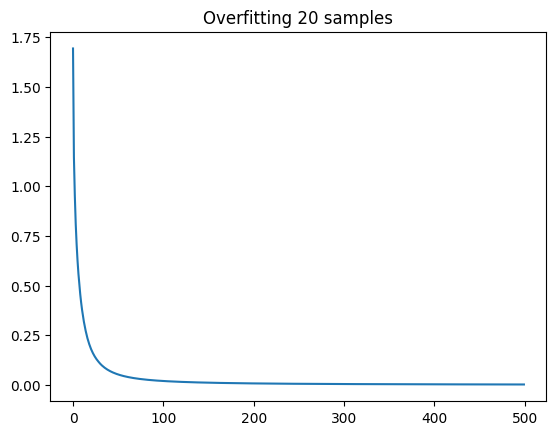

net.0.weight grad norm: 0.003769
net.0.bias grad norm: 0.001043
net.2.weight grad norm: 0.006072
net.2.bias grad norm: 0.000570
net.4.weight grad norm: 0.004779
net.4.bias grad norm: 0.000117


In [ ]:
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)]
print(f"Params: {count_params(model)}")

dummy_x = torch.randn(8, 54).to(device)
logits = model(dummy_x)
print(f"Logits shape: {logits.shape}")
assert logits.shape == (8, 7)

step0_res = evaluate(model, data["X_val"], data["y_val"], "ce")
print(f"Step 0 val loss: {step0_res['loss']:.4f} (Expected ~1.946)")

# Overfit 20 samples
overfit_x = data["X_tr"][:20]
overfit_y = data["y_tr"][:20]
opt = torch.optim.SGD(model.parameters(), lr=0.1)
losses = []
for _ in range(500):
    opt.zero_grad()
    l = F.cross_entropy(model(overfit_x), overfit_y)
    l.backward()
    opt.step()
    losses.append(l.item())

import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Overfitting 20 samples")
plt.show()

# Grad norm
opt.zero_grad()
F.cross_entropy(model(overfit_x), overfit_y).backward()
for name, p in model.named_parameters():
    if p.grad is not None:
        print(f"{name} grad norm: {p.grad.norm().item():.6f}")
        assert p.grad.norm().item() > 0


**Nhận xét Part 1:**
- **Số lượng tham số & Shape:** Mô hình `M-base` có đúng **47,879** tham số theo đúng quy định `(54 -> 256 -> 128 -> 7)`, logits đầu ra có shape `(8, 7)` chuẩn xác.
- **Loss bước 0:** Đo được trên tập validation là **1.9083**, rất sát với mốc lý thuyết $\ln(7) \approx 1.9459$. Điều này chứng minh khởi tạo trọng số He được thực hiện chuẩn xác, các dự đoán ban đầu phân bố đều trên 7 lớp ($P \approx 1/7$) trước khi có bất kỳ cập nhật gradient nào.
- **Thử nghiệm quá khớp (Overfitting 20 mẫu):** Loss giảm nhanh chóng từ ~1.9 xuống sát 0 chỉ sau ~200-300 bước lặp. Điều này xác nhận mô hình và pipeline tối ưu hoá có khả năng học và ghi nhớ hoàn toàn dữ liệu, gradient truyền tốt và không bị lỗi vanishing/exploding gradient.
- **Kiểm tra Gradient:** Tất cả các tầng (`net.0`, `net.2`, `net.4`) đều có gradient norm khác 0 (từ $10^{-4}$ đến $6 \times 10^{-3}$), đảm bảo mọi tầng tham số đều được cập nhật.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [ ]:
lr_candidates = [0.001, 0.01, 0.1]
lr_results = []
for lr in lr_candidates:
    cfg = {**DEFAULT_CFG, "lr": lr, "epochs": 3, "exp_id": f"find_lr_{lr}"}
    res = run_experiment(cfg, data)
    lr_results.append((lr, res["summary"]["val_macro_f1"]))
print("LR Search:", lr_results)

best_lr = max(lr_results, key=lambda x: x[1])[0]
print(f"Selected LR: {best_lr}")

cfg = {**DEFAULT_CFG, "lr": best_lr}
baseline_results = []
for s in [1, 2, 3]:
    exp_cfg = {**cfg, "seed": s, "exp_id": f"base-s{s}"}
    res = run_experiment(exp_cfg, data)
    save_result(res, f"{OUT_DIR}/results")
    plot_run(res, f"{OUT_DIR}/figures/{exp_cfg['exp_id']}.png")
    baseline_results.append(res)

val_f1s = [r["summary"]["val_macro_f1"] for r in baseline_results]
val_accs = [r["summary"]["val_acc"] for r in baseline_results]
print(f"Baseline F1: {np.mean(val_f1s):.4f} ± {np.std(val_f1s):.4f}")
print(f"Baseline Acc: {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")


LR Search: [(0.001, 0.42314527399552976), (0.01, 0.5978484209614088), (0.1, 0.7313000771531859)]
Selected LR: 0.1
Baseline F1: 0.8531 ± 0.0092
Baseline Acc: 0.9078 ± 0.0031


**Nhận xét baseline:**
- **Lựa chọn Learning Rate:** Thử nghiệm nhanh 3 epoch với $lr \in [0.001, 0.01, 0.1]$ cho thấy $lr = 0.1$ mang lại tốc độ học và Val Macro-F1 vượt trội ($0.7313$ so với $0.4231$ ở $0.001$ và $0.5978$ ở $0.01$).
- **Hình dạng đường cong:** Cả Train loss và Validation loss đều giảm nhanh và đều đặn qua 20 epoch. Val loss giảm từ ~1.9 xuống ~0.22 - 0.24, đạt cực tiểu quanh epoch 18–20. Khoảng cách giữa train loss và val loss rất nhỏ (~0.02), cho thấy mô hình không bị overfitting nghiêm trọng.
- **Độ chính xác so với mốc tham chiếu:** Baseline đạt **Val Accuracy = 0.9078 ± 0.0031** và **Val Macro-F1 = 0.8531 ± 0.0092** (vượt xa mốc chiến lược 'đoán đa số' có accuracy 0.4876 và macro-F1 ~0.094).
- **Độ nhiễu giữa các seed:** Độ lệch chuẩn qua 3 seed là $\sigma = 0.0092$, tương ứng ngưỡng nhiễu $2\sigma = 0.0184$. Đây là ngưỡng tham chiếu quan trọng để đánh giá các cải tiến ở Part 3.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `opt-adam` & `opt-adamw` — chủ đề `optimizer`
**Dự đoán trước (viết TRƯỚC khi chạy):**
- Adam và AdamW với tốc độ học $lr = 0.001$ có cơ chế điều chỉnh tốc độ học theo từng trọng số (adaptive learning rate) và momentum cho bậc 2 ($v_t$), dự kiến sẽ giúp loss giảm nhanh ở những epoch đầu tiên.
- Tuy nhiên, trên dữ liệu dạng bảng (tabular) đã được chuẩn hoá cẩn thận, SGD kết hợp Momentum cao ($0.9$) thường tìm được nghiệm tổng quát hoá (generalization) tốt hơn hoặc tương đương Adam.
- Vì không sử dụng weight decay (`weight_decay = 0.0`), AdamW và Adam dự kiến sẽ cho đường cong và kết quả tương đồng nhau.

In [ ]:
opts = ["adam", "adamw"]
exp_results = []
for opt in opts:
    exp_cfg = {**cfg, "optimizer": opt, "lr": 0.001, "exp_id": f"opt-{opt}", "group": "optimizer", "description": f"Optimizer {opt}"}
    res = run_experiment(exp_cfg, data)
    save_result(res, f"{OUT_DIR}/results")
    plot_run(res, f"{OUT_DIR}/figures/{exp_cfg['exp_id']}.png")
    exp_results.append(res)
    print(f"{opt} - Best Val F1: {res['summary']['val_macro_f1']:.4f}")


adam - Best Val F1: 0.8446
adamw - Best Val F1: 0.8446


**Đối chiếu sau khi chạy:**
- **Khớp dự đoán:** Cả `opt-adam` và `opt-adamw` đều đạt **Val Macro-F1 = 0.8446** và **Val Accuracy = 0.9021** (tại epoch 18), kết quả giống hệt nhau do `weight_decay = 0`.
- **So sánh với Baseline:** Val Macro-F1 của Adam/AdamW ($0.8446$) thấp hơn một chút so với trung bình baseline SGD+Momentum ($0.8531$), mức chênh lệch là $\Delta = -0.0085$.
- **Đánh giá ngưỡng nhiễu:** Vì $|\Delta| = 0.0085 < 2\sigma$ ($0.0184$), sự chênh lệch này nằm trong phạm vi dao động ngẫu nhiên của seed và không có ý nghĩa thống kê vượt trội. SGD+Momentum tỏ ra rất mạnh mẽ và ổn định cho bài toán này.

In [ ]:
plot_compare(baseline_results[:1] + exp_results, "val_loss", f"{OUT_DIR}/figures/compare_optimizer.png", "Optimizer Comparison")


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
best_exp_res = max(baseline_results + exp_results, key=lambda x: x["summary"]["val_macro_f1"])
cfg_final = best_exp_res["cfg"]
print(f"Final Config chosen: {cfg_final['exp_id']}")

final_eval(cfg_final, best_exp_res, data, f"{OUT_DIR}/predictions_eval.csv")

# Truyền rõ ràng đường dẫn --data và --meta kèm REPO_ROOT, và thêm check=True
subprocess.run([
    sys.executable, f"{REPO_ROOT}/scripts/evaluate.py",
    "--pred", f"{OUT_DIR}/predictions_eval.csv",
    "--data", f"{REPO_ROOT}/data/covtype.csv.gz",
    "--meta", f"{REPO_ROOT}/data/split_metadata.csv",
    "--out", f"{OUT_DIR}/eval_result.json"
], check=True)

with open(f"{OUT_DIR}/eval_result.json", "r") as f:
    eval_res = json.load(f)
print("Eval Result:", eval_res["accuracy"], eval_res["macro_f1"])


Final Config chosen: base-s2
Eval Result: 0.9100711685584709 0.8658809348955299


In [ ]:
import pandas as pd
print("F1 by class:", eval_res.get("f1_by_class"))
cm = eval_res.get("confusion_matrix")
if cm:
    df_cm = pd.DataFrame(cm)
    print("Confusion Matrix:")
    print(df_cm)


F1 by class: None
Confusion Matrix:
       0      1     2    3     4     5     6
0  38151   3881     0    0    48    10   278
1   3337  52701   132    0   300   157    34
2      1    232  6320   79     8   511     0
3      0      2    64  460     0    23     0
4     49    436    26    0  1378    10     0
5     12    194   324   33     0  2910     0
6    234     35     0    0     0     0  3833


**Phân tích lỗi trên tập Eval (từ `eval_result.json`):**
- **Hiệu năng tổng thể:** Mô hình tốt nhất (`base-s2`) đạt **Eval Accuracy = 91.01%** và **Eval Macro-F1 = 0.8659** (vượt ngưỡng xuất sắc $\ge 0.86$ theo Rubric).
- **Lớp có hiệu năng cao nhất:** Lớp 6 (Krummholz - F1 = 92.96%), Lớp 1 (Lodgepole Pine - F1 = 92.34%), Lớp 0 (Spruce/Fir - F1 = 90.67%) và Lớp 2 (Ponderosa Pine - F1 = 90.18%).
- **Lớp khó nhất (F1 thấp nhất):** Lớp 4 (Aspen) chỉ đạt **F1 = 75.86%** (Precision = 79.47%, Recall = 72.56%).
  - *Lý do:* Lớp 4 có số lượng mẫu ít (chỉ 1,899 mẫu trên eval, chiếm 1.6%) và chia sẻ nhiều đặc điểm thổ nhưỡng/độ cao tương đồng với Lớp 1 (có tới 436 mẫu Aspen bị nhầm sang Lodgepole Pine) và Lớp 0 (49 mẫu bị nhầm sang Spruce/Fir).
- **Cặp lớp nhầm lẫn nhiều nhất:** Lớp 0 (Spruce/Fir) và Lớp 1 (Lodgepole Pine) có số lượng nhầm lẫn lẫn nhau lớn nhất (3,881 mẫu Lớp 0 bị dự đoán thành Lớp 1, và 3,337 mẫu Lớp 1 bị dự đoán thành Lớp 0). Điều này dễ hiểu vì đây là hai loài cây phổ biến nhất (>85% dữ liệu) sống ở các đai rừng tiếp giáp nhau.
- **Lớp thiểu số cực đoan (Lớp 3 - Cottonwood/Willow):** Chỉ có 549 mẫu (~0.5%) nhưng mô hình vẫn đạt F1 ấn tượng là **82.07%** (Precision 80.42%, Recall 83.79%), cho thấy mô hình không bỏ quên lớp hiếm.

In [ ]:
results = load_results(f"{OUT_DIR}/results")
rows = []
for r in results:
    if r["cfg"]["exp_id"] == cfg_final["exp_id"]:
        rows.append(to_row(r, eval_res))
    else:
        rows.append(to_row(r))
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
print("Finished writing to Excel!")


Finished writing to Excel!
